In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Chemins
ML_REPORTS_PATH = "../reports/ml"
EVAL_REPORTS_PATH = "../reports/evaluation"
EVAL_FIGURES_PATH = "../reports/figures/evaluation"

os.makedirs(EVAL_REPORTS_PATH, exist_ok=True)
os.makedirs(EVAL_FIGURES_PATH, exist_ok=True)

# Chargement des résultats du machine learning

model_results = pd.read_csv(
    f"{ML_REPORTS_PATH}/model_results.csv"
)

predictions = pd.read_csv(
    f"{ML_REPORTS_PATH}/predictions_test.csv"
)

feature_importance = pd.read_csv(
    f"{ML_REPORTS_PATH}/feature_importance.csv"
)

# Conversion de la date

predictions["date_mois"] = pd.to_datetime(
    predictions["date_mois"],
    errors="coerce"
)

print("Fichiers chargés avec succès")
print("model_results :", model_results.shape)
print("predictions :", predictions.shape)
print("feature_importance :", feature_importance.shape)

model_results

Fichiers chargés avec succès
model_results : (4, 5)
predictions : (485, 38)
feature_importance : (20, 2)


,model,MAE,RMSE,R2,WAPE
0,Gradient Boosting,19.657198,77.525792,0.873507,35.849218
1,Random Forest,20.003727,78.101240,0.871622,36.481189
2,Ridge Regression,23.511114,82.329182,0.857347,42.877681
3,Naive M1,20.315464,87.026634,0.840603,37.049710


In [2]:
# Résultats des modèles entraînés

trained_results = model_results[
    model_results["model"] != "Naive M1"
].sort_values("RMSE")

best_model_row = trained_results.iloc[0]

best_model_name = best_model_row["model"]
best_mae = best_model_row["MAE"]
best_rmse = best_model_row["RMSE"]
best_r2 = best_model_row["R2"]
best_wape = best_model_row["WAPE"]

# Résultat du modèle naïf

baseline_row = model_results[
    model_results["model"] == "Naive M1"
].iloc[0]

baseline_rmse = baseline_row["RMSE"]

amelioration_rmse = (
    (baseline_rmse - best_rmse)
    / baseline_rmse
    * 100
)

print("Meilleur modèle :", best_model_name)
print("MAE :", round(best_mae, 3))
print("RMSE :", round(best_rmse, 3))
print("R² :", round(best_r2, 3))
print("WAPE :", round(best_wape, 2), "%")

print(
    "Amélioration par rapport au modèle naïf :",
    round(amelioration_rmse, 2),
    "%"
)

Meilleur modèle : Gradient Boosting
MAE : 19.657
RMSE : 77.526
R² : 0.874
WAPE : 35.85 %
Amélioration par rapport au modèle naïf : 10.92 %


In [3]:
# Valeurs réelles et prédites

y_true = predictions["quantite_reelle"]
y_pred = predictions["quantite_predite"]

# Calcul des erreurs

predictions["residual"] = (
    y_true - y_pred
)

predictions["absolute_error"] = (
    predictions["residual"].abs()
)

# Métriques

mae = mean_absolute_error(
    y_true,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

r2 = r2_score(
    y_true,
    y_pred
)

wape = (
    predictions["absolute_error"].sum()
    / y_true.sum()
    * 100
)

mean_error = predictions["residual"].mean()

bias_percent = (
    (y_pred.sum() - y_true.sum())
    / y_true.sum()
    * 100
)

percentage_zero = (
    y_true.eq(0).mean()
    * 100
)

# Tableau résumé

evaluation_summary = pd.DataFrame([{
    "best_model": best_model_name,
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "WAPE_percent": wape,
    "mean_error": mean_error,
    "bias_percent": bias_percent,
    "improvement_vs_naive_percent": amelioration_rmse,
    "zero_demand_percent": percentage_zero,
    "total_real": y_true.sum(),
    "total_predicted": y_pred.sum(),
    "nb_predictions": len(predictions)
}])

evaluation_summary.to_csv(
    f"{EVAL_REPORTS_PATH}/evaluation_summary.csv",
    index=False
)

evaluation_summary

,best_model,MAE,RMSE,R2,WAPE_percent,mean_error,bias_percent,improvement_vs_naive_percent,zero_demand_percent,total_real,total_predicted,nb_predictions
0,Gradient Boosting,19.657198,77.525792,0.873507,35.849218,1.433148,-2.613659,10.917166,49.072165,26594.0,25898.923393,485


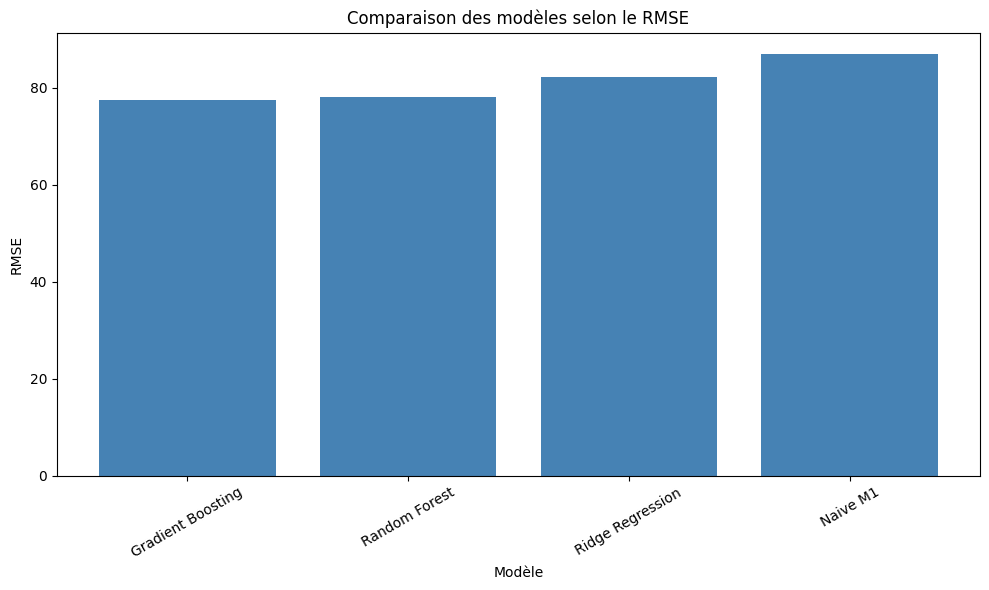

,model,MAE,RMSE,R2,WAPE
0,Gradient Boosting,19.657198,77.525792,0.873507,35.849218
1,Random Forest,20.003727,78.101240,0.871622,36.481189
2,Ridge Regression,23.511114,82.329182,0.857347,42.877681
3,Naive M1,20.315464,87.026634,0.840603,37.049710


In [4]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_results["model"],
    model_results["RMSE"],
    color="steelblue"
)

plt.title("Comparaison des modèles selon le RMSE")
plt.xlabel("Modèle")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    f"{EVAL_FIGURES_PATH}/model_metrics_comparison.png"
)

plt.show()
plt.close()

model_results

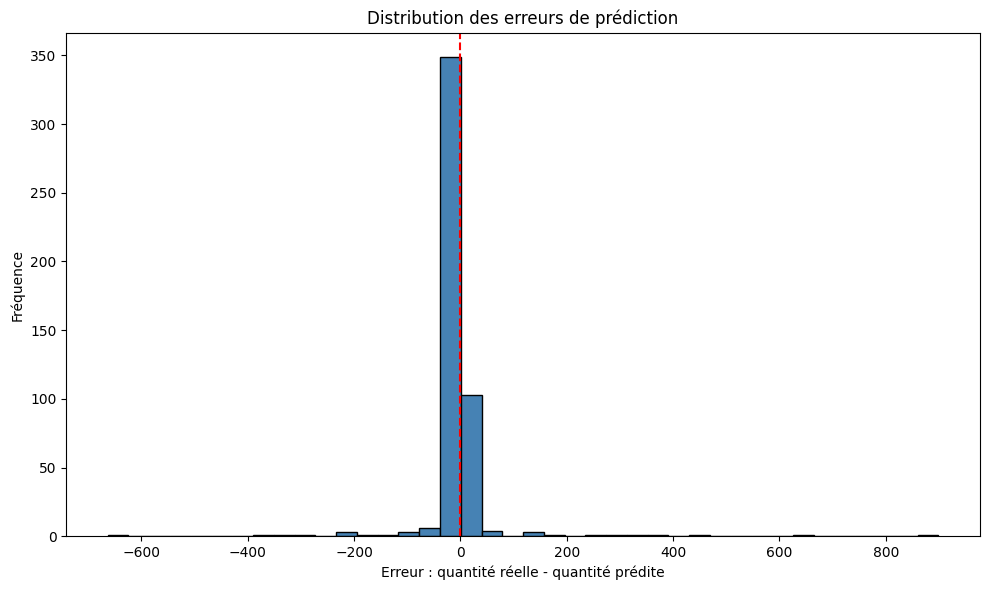

,quantite_reelle,quantite_predite,residual,absolute_error
count,485.000000,485.000000,485.000000,485.000000
mean,54.832990,53.399842,1.433148,19.657198
std,218.203046,205.310903,77.592578,75.069718
min,0.000000,1.396785,-663.403784,0.139871
25%,0.000000,1.695722,-3.046065,1.617173
50%,1.000000,2.368044,-1.617173,2.355553
75%,9.000000,8.433068,0.484684,7.168558
max,1802.000000,1531.403784,899.024654,899.024654


In [5]:
plt.figure(figsize=(10, 6))

plt.hist(
    predictions["residual"],
    bins=40,
    color="steelblue",
    edgecolor="black"
)

plt.axvline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Distribution des erreurs de prédiction")
plt.xlabel("Erreur : quantité réelle - quantité prédite")
plt.ylabel("Fréquence")
plt.tight_layout()

plt.savefig(
    f"{EVAL_FIGURES_PATH}/residual_distribution.png"
)

plt.show()
plt.close()

predictions[
    [
        "quantite_reelle",
        "quantite_predite",
        "residual",
        "absolute_error"
    ]
].describe()

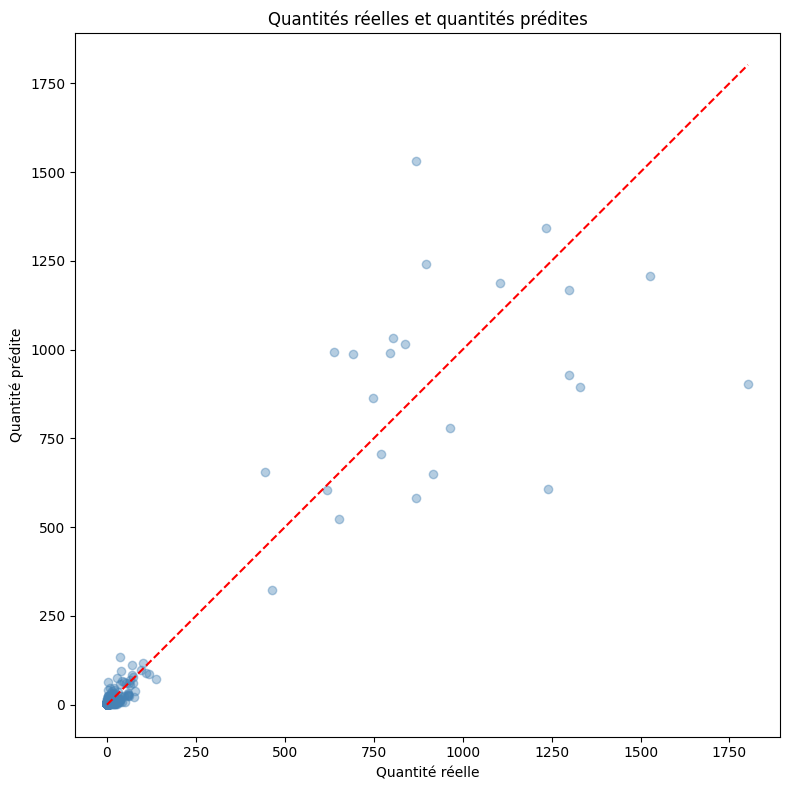

In [6]:
plt.figure(figsize=(8, 8))

plt.scatter(
    predictions["quantite_reelle"],
    predictions["quantite_predite"],
    alpha=0.4,
    color="steelblue"
)

max_value = max(
    predictions["quantite_reelle"].max(),
    predictions["quantite_predite"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    color="red",
    linestyle="--"
)

plt.title("Quantités réelles et quantités prédites")
plt.xlabel("Quantité réelle")
plt.ylabel("Quantité prédite")
plt.tight_layout()

plt.savefig(
    f"{EVAL_FIGURES_PATH}/real_vs_predicted_scatter.png"
)

plt.show()
plt.close()

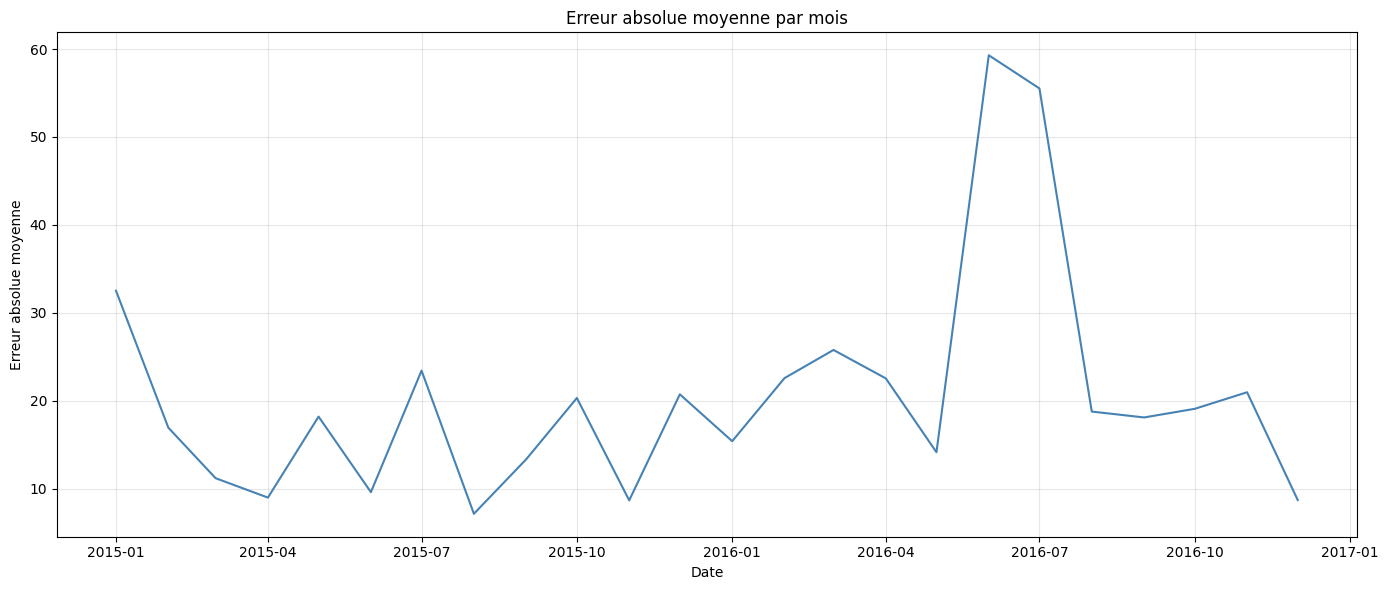

,annee,mois,absolute_error,total_absolute_error,residual,quantite_reelle,quantite_predite,WAPE,date
0,2015,1,32.511605,812.790129,19.337872,1383.0,899.553198,58.770074,2015-01-01
1,2015,2,16.932707,406.384964,11.360946,1650.0,1377.337304,24.629392,2015-02-01
2,2015,3,11.184079,279.601977,5.402923,1466.0,1330.926924,19.072440,2015-03-01
3,2015,4,8.977137,242.382710,-0.052746,1341.0,1342.424138,18.074773,2015-04-01
4,2015,5,18.189912,491.127612,-13.953036,795.0,1171.731980,61.777058,2015-05-01


In [7]:
predictions["annee"] = (
    predictions["date_mois"].dt.year
)

predictions["mois"] = (
    predictions["date_mois"].dt.month
)

error_by_month = (
    predictions
    .groupby(
        ["annee", "mois"],
        as_index=False
    )
    .agg(
        absolute_error=("absolute_error", "mean"),
        total_absolute_error=("absolute_error", "sum"),
        residual=("residual", "mean"),
        quantite_reelle=("quantite_reelle", "sum"),
        quantite_predite=("quantite_predite", "sum")
    )
)

error_by_month["WAPE"] = (
    error_by_month["total_absolute_error"]
    / error_by_month["quantite_reelle"].replace(0, np.nan)
    * 100
)

error_by_month["date"] = pd.to_datetime(
    error_by_month["annee"].astype(str)
    + "-"
    + error_by_month["mois"].astype(str)
    + "-01"
)

error_by_month.to_csv(
    f"{EVAL_REPORTS_PATH}/error_by_month.csv",
    index=False
)

plt.figure(figsize=(14, 6))

plt.plot(
    error_by_month["date"],
    error_by_month["absolute_error"],
    color="steelblue"
)

plt.title("Erreur absolue moyenne par mois")
plt.xlabel("Date")
plt.ylabel("Erreur absolue moyenne")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{EVAL_FIGURES_PATH}/error_by_month.png"
)

plt.show()
plt.close()

error_by_month.head()

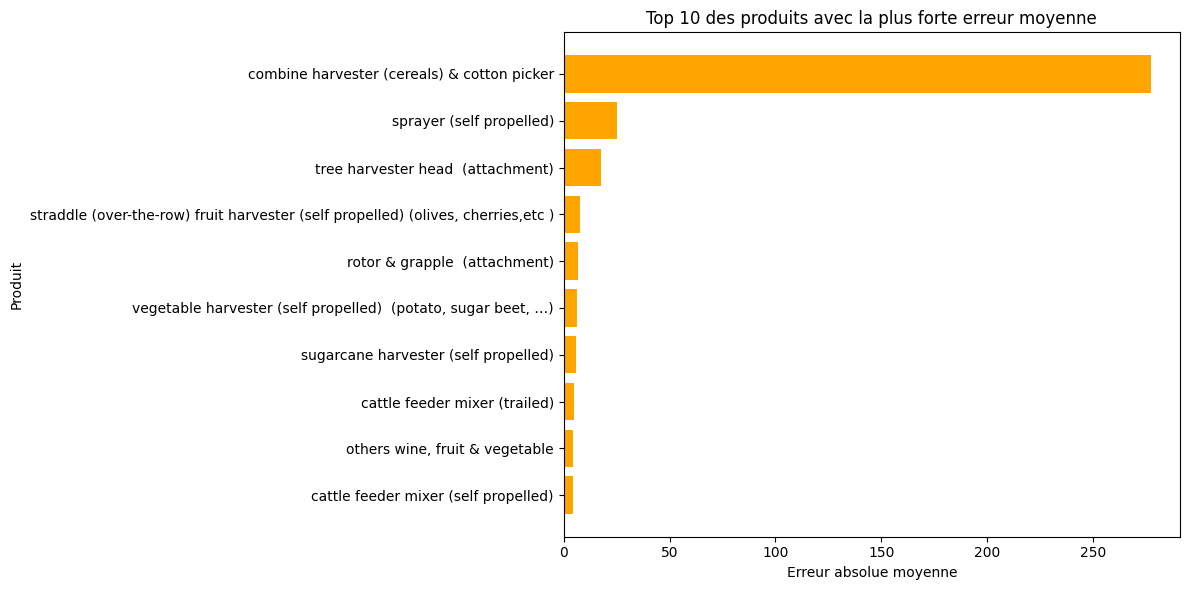

,produit,absolute_error,total_absolute_error,residual,quantite_reelle,quantite_predite,nb_predictions,WAPE
4,combine harvester (cereals) & cotton picker,277.117450,6650.818806,45.372343,22814.0,21725.063780,24,29.152357
12,sprayer (self propelled),25.249990,605.999755,-7.068873,1495.0,1664.652953,24,40.535101
19,tree harvester head (attachment),17.645176,846.968434,2.399049,1131.0,1015.845643,48,74.886687
15,straddle (over-the-row) fruit harvester (self ...,7.537736,165.830188,1.246595,172.0,144.574901,22,96.412900
11,rotor & grapple (attachment),6.577450,98.661744,0.216419,62.0,58.753719,15,159.131844
23,"vegetable harvester (self propelled) (potato,...",6.297524,151.140581,2.241336,251.0,197.207928,24,60.215371
16,sugarcane harvester (self propelled),5.868327,134.971531,-0.312544,134.0,141.188512,23,100.725023
3,cattle feeder mixer (trailed),4.917262,44.255361,-0.096939,39.0,39.872455,9,113.475284
10,"others wine, fruit & vegetable",4.484781,62.786931,-0.715805,30.0,40.021276,14,209.289769
2,cattle feeder mixer (self propelled),4.420718,203.353048,-0.698581,223.0,255.134704,46,91.189708


In [8]:
error_by_product = (
    predictions
    .groupby(
        "produit",
        as_index=False
    )
    .agg(
        absolute_error=("absolute_error", "mean"),
        total_absolute_error=("absolute_error", "sum"),
        residual=("residual", "mean"),
        quantite_reelle=("quantite_reelle", "sum"),
        quantite_predite=("quantite_predite", "sum"),
        nb_predictions=("produit", "size")
    )
)

error_by_product["WAPE"] = (
    error_by_product["total_absolute_error"]
    / error_by_product["quantite_reelle"].replace(0, np.nan)
    * 100
)

error_by_product = error_by_product.sort_values(
    "absolute_error",
    ascending=False
)

error_by_product.to_csv(
    f"{EVAL_REPORTS_PATH}/error_by_product.csv",
    index=False
)

top_error_products = (
    error_by_product.head(10)
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_error_products["produit"],
    top_error_products["absolute_error"],
    color="orange"
)

plt.title("Top 10 des produits avec la plus forte erreur moyenne")
plt.xlabel("Erreur absolue moyenne")
plt.ylabel("Produit")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    f"{EVAL_FIGURES_PATH}/top_error_products.png"
)

plt.show()
plt.close()

top_error_products

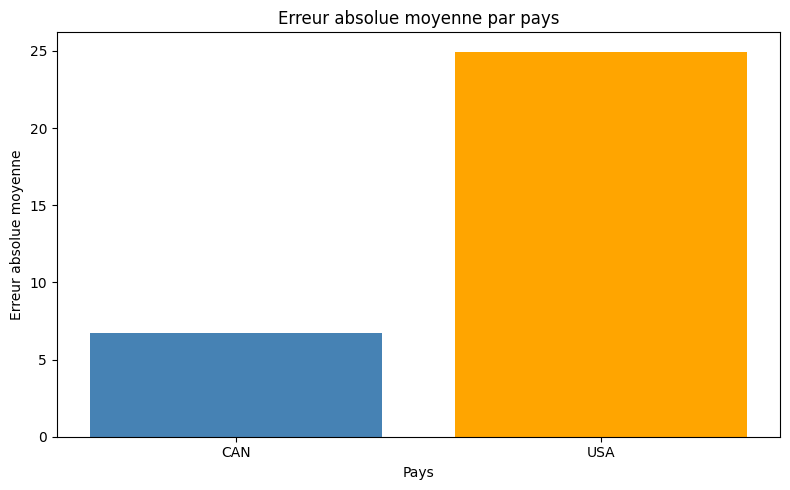

Résultat par région :


,region,absolute_error,total_absolute_error,residual,quantite_reelle,quantite_predite,WAPE
0,Northern America,19.657198,9533.741075,1.433148,26594.0,25898.923393,35.849218


Résultat par pays :


,code_pays,pays,absolute_error,total_absolute_error,residual,quantite_reelle,quantite_predite,WAPE
0,CAN,canada,6.728884,948.772608,-0.576942,1057.0,1138.348800,89.760890
1,USA,united states,24.956304,8584.968467,2.257051,25537.0,24760.574593,33.617764


In [9]:
# Erreur par région

error_by_region = (
    predictions
    .groupby(
        "region",
        as_index=False
    )
    .agg(
        absolute_error=("absolute_error", "mean"),
        total_absolute_error=("absolute_error", "sum"),
        residual=("residual", "mean"),
        quantite_reelle=("quantite_reelle", "sum"),
        quantite_predite=("quantite_predite", "sum")
    )
)

error_by_region["WAPE"] = (
    error_by_region["total_absolute_error"]
    / error_by_region["quantite_reelle"].replace(0, np.nan)
    * 100
)

error_by_region.to_csv(
    f"{EVAL_REPORTS_PATH}/error_by_region.csv",
    index=False
)

# Erreur par pays

error_by_country = (
    predictions
    .groupby(
        ["code_pays", "pays"],
        as_index=False
    )
    .agg(
        absolute_error=("absolute_error", "mean"),
        total_absolute_error=("absolute_error", "sum"),
        residual=("residual", "mean"),
        quantite_reelle=("quantite_reelle", "sum"),
        quantite_predite=("quantite_predite", "sum")
    )
)

error_by_country["WAPE"] = (
    error_by_country["total_absolute_error"]
    / error_by_country["quantite_reelle"].replace(0, np.nan)
    * 100
)

error_by_country.to_csv(
    f"{EVAL_REPORTS_PATH}/error_by_country.csv",
    index=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    error_by_country["code_pays"],
    error_by_country["absolute_error"],
    color=["steelblue", "orange"]
)

plt.title("Erreur absolue moyenne par pays")
plt.xlabel("Pays")
plt.ylabel("Erreur absolue moyenne")
plt.tight_layout()

plt.savefig(
    f"{EVAL_FIGURES_PATH}/error_by_country.png"
)

plt.show()
plt.close()

print("Résultat par région :")
display(error_by_region)

print("Résultat par pays :")
display(error_by_country)

In [10]:
top_features = (
    feature_importance.head(15)
)

print("Top 15 des variables importantes :")

display(top_features)

top_features.to_csv(
    f"{EVAL_REPORTS_PATH}/top_features_interpretation.csv",
    index=False
)

Top 15 des variables importantes :


,feature,importance
0,num__vente_M1,0.885272
1,num__soybean_price_M1,0.026148
2,num__moyenne_mobile_3,0.020439
3,num__vente_M12,0.011408
4,cat__mois_10,0.010472
5,num__precipitation_M1,0.009335
6,num__vente_M2,0.008796
7,num__wheat_price_M1,0.006686
8,num__corn_price_M1,0.006354
9,num__temperature_M1,0.005161


In [11]:
resume = f"""
Résumé de l'évaluation du modèle

Modèle retenu :
{best_model_name}

Période de test :
de {predictions['date_mois'].min()} à {predictions['date_mois'].max()}

Nombre de prédictions :
{len(predictions)}

Performances globales :

- MAE : {mae:.3f}
- RMSE : {rmse:.3f}
- R² : {r2:.3f}
- WAPE : {wape:.2f} %
- Biais moyen : {mean_error:.3f}
- Biais total : {bias_percent:.2f} %
- Amélioration par rapport au modèle naïf : {amelioration_rmse:.2f} %

Interprétation :

Le modèle Gradient Boosting obtient de meilleures performances que le modèle
naïf basé sur les ventes du mois précédent.

Le modèle améliore le RMSE de {amelioration_rmse:.2f} % par rapport au modèle
naïf. Le R² indique la part de variance expliquée par le modèle.

Le WAPE est utilisé à la place du MAPE, car le dataset contient de nombreux
mois sans vente.

Les erreurs ont été analysées par mois, par produit et par pays. Une erreur
positive correspond à une sous-estimation et une erreur négative correspond
à une surestimation.

Le modèle est évalué dans le cadre d'une prévision mensuelle glissante à un
mois. Les ventes du mois précédent sont donc connues au moment de la
prédiction.

Les variables les plus importantes sont disponibles dans le fichier
feature_importance.csv.

Conclusion :

Le modèle apporte une amélioration mesurable par rapport au modèle naïf.
Les résultats peuvent maintenant être préparés pour la visualisation dans
Power BI et pour la rédaction du mémoire.
"""

with open(
    f"{EVAL_REPORTS_PATH}/evaluation_resume.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(resume)

print(resume)


Résumé de l'évaluation du modèle

Modèle retenu :
Gradient Boosting

Période de test :
de 2015-01-01 00:00:00 à 2016-12-01 00:00:00

Nombre de prédictions :
485

Performances globales :

- MAE : 19.657
- RMSE : 77.526
- R² : 0.874
- WAPE : 35.85 %
- Biais moyen : 1.433
- Biais total : -2.61 %
- Amélioration par rapport au modèle naïf : 10.92 %

Interprétation :

Le modèle Gradient Boosting obtient de meilleures performances que le modèle
naïf basé sur les ventes du mois précédent.

Le modèle améliore le RMSE de 10.92 % par rapport au modèle
naïf. Le R² indique la part de variance expliquée par le modèle.

Le WAPE est utilisé à la place du MAPE, car le dataset contient de nombreux
mois sans vente.

Les erreurs ont été analysées par mois, par produit et par pays. Une erreur
positive correspond à une sous-estimation et une erreur négative correspond
à une surestimation.

Le modèle est évalué dans le cadre d'une prévision mensuelle glissante à un
mois. Les ventes du mois précédent sont do

In [12]:
expected_files = [
    f"{EVAL_REPORTS_PATH}/evaluation_summary.csv",
    f"{EVAL_REPORTS_PATH}/evaluation_resume.txt",
    f"{EVAL_REPORTS_PATH}/error_by_product.csv",
    f"{EVAL_REPORTS_PATH}/error_by_region.csv",
    f"{EVAL_REPORTS_PATH}/error_by_country.csv",
    f"{EVAL_REPORTS_PATH}/error_by_month.csv",
    f"{EVAL_REPORTS_PATH}/top_features_interpretation.csv",
    f"{EVAL_FIGURES_PATH}/model_metrics_comparison.png",
    f"{EVAL_FIGURES_PATH}/residual_distribution.png",
    f"{EVAL_FIGURES_PATH}/real_vs_predicted_scatter.png",
    f"{EVAL_FIGURES_PATH}/error_by_month.png",
    f"{EVAL_FIGURES_PATH}/top_error_products.png",
    f"{EVAL_FIGURES_PATH}/error_by_country.png"
]

for file in expected_files:
    print(file, os.path.exists(file))

../reports/evaluation/evaluation_summary.csv True
../reports/evaluation/evaluation_resume.txt True
../reports/evaluation/error_by_product.csv True
../reports/evaluation/error_by_region.csv True
../reports/evaluation/error_by_country.csv True
../reports/evaluation/error_by_month.csv True
../reports/evaluation/top_features_interpretation.csv True
../reports/figures/evaluation/model_metrics_comparison.png True
../reports/figures/evaluation/residual_distribution.png True
../reports/figures/evaluation/real_vs_predicted_scatter.png True
../reports/figures/evaluation/error_by_month.png True
../reports/figures/evaluation/top_error_products.png True
../reports/figures/evaluation/error_by_country.png True
